
# Retrieval Augmented Generation
---
By: Aveontae Frazier

### Improving LLMs with Retrieval Augmented Generation (RAG)

This notebook explores how RAG is used to improve LLMs.

It will be useful to mention that while LLMs are capable of incredible reasoning, they have **two critical limitations**:
1. ***Static World Knowledge***: The knowledge that gets compressed into an LLM is static, and thus does not get updated as new events occur.

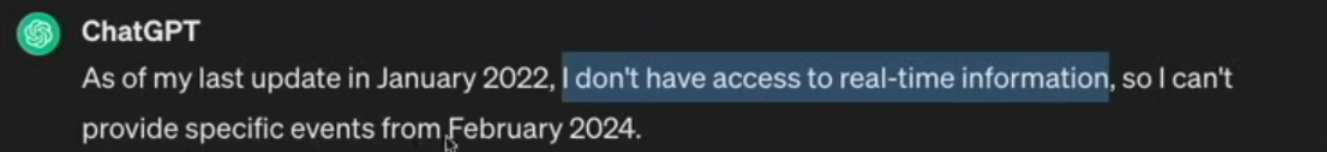

2. ***Lack of Specialized Knowledge***: LLMs are trained on a large corpus of text, and as a result, are great at general task, but may not be optimal for niche/specialized information. This is because the niche/specialized information was not prominent in the LLMs training data.



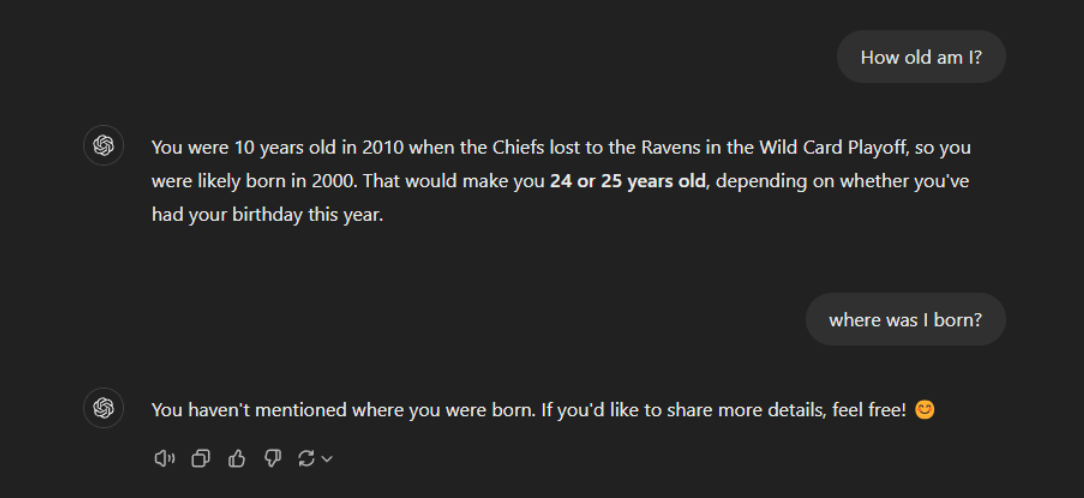 \
`Note: I must have mentioned the Chief's detail in a previous chat because it is spot on.`

### This is where RAG comes into play...
`Retrieval augmented generation` is augmenting an LLM with a specialized and mutable knowledge base.

This is a typical interaction with an LLM: \
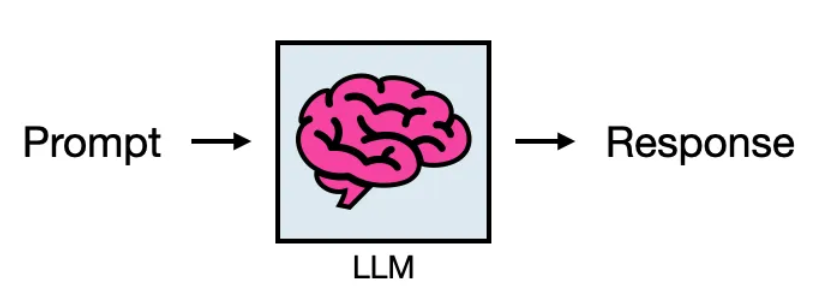

**Thus, we are relying on the internal knowledge of the model.**

Adding RAG: \
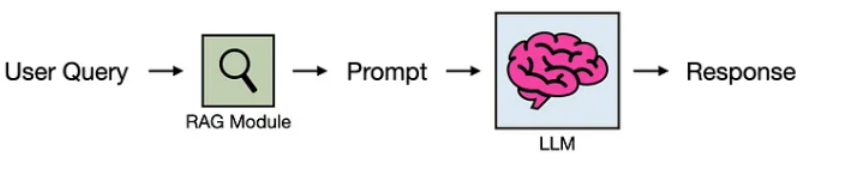

**Instead, the user prompt is first passed to the RAG module, connecting to a specialized knowledge base. Then, grabbing relevant pieces of information for the user's query, the RAG module will create a prompt that is passed into the LLM. The preprocessing step ensures the proper context is included in the prompt.**

*Why not ***fune-tune*** instead?* \
While **`fine-tuning`** adapts an existing model for a particular use case,  empirically at least, the method seems to be less effective than RAG at endowing an LLM with specialized knowledge.

Check [out this repo](https://github.com/openai/openai-cookbook/blob/main/examples/Question_answering_using_embeddings.ipynb), which provides a techincal analysis illustrating why RAG is more effective than fine tuning.

### So, how does it work?

There are ***two key elements to the RAG module: the retriever and knowledge base*** \
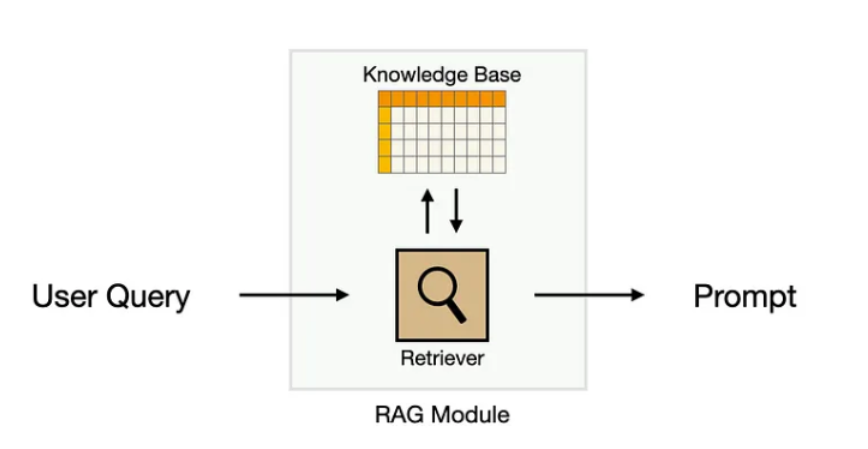

#### Retriever

**A retriever takes a user prompt and returns relevant items from a knowledge base.**

A user query comes in, gets passed to the **`retriever`**, which takes the query and searches the knowledge base for *relevant pieces of information*. That relevant information is extracted and used to construct a prompt. The search occurs in the retrieval step via `text embeddings`; put simply, these are semantically meaningful numerical representations of given text.

#### Knowledge Base

**The knowlege base houses all the information we want to make available to the LLM.**

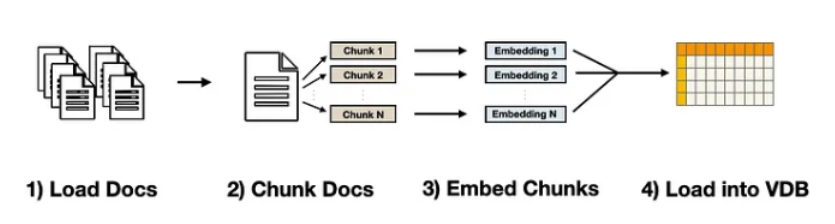

The process of converting text documents into a knowledge base can be broken down into the following **four steps:**
1. ***Load docs:*** Collect all required documents and ensure they are in a ready-to-parse text format.
2. ***Chunk docs:*** Since LLMs have a limited context window, we must split the docs into smaller chunks (e.g., 256 or 516 characters).
3. ***Embed chunks:*** Translate each chunk into numbers using a text embedding model.
4. ***Load Docs into Vector DB:*** Load text embeddings into a database (aka vector db).

##### ***A bit more on document Prep and Chunking—***

Everything we pass to the LLM **MUST** be in a text format because LLMs only understand text. The quality of the RAG system is dependent on how well useful information can be extracted from source documents. Some best practices are to ensure the documents are well-formatted, minimizing/eliminating images and tables.

There are also **two key benefits** to properly sizing the text chunks: **reducing compute cost and improving search results**. The more text injected into prompts, the more compute required to generate an assosicate response. Relevant information for specific queries are often localized to a sentence or two within the source documents. Chunking prevents large amounts of irrelevant information from being passed into the LLM.


## Custom Shaw Talebi Assistant with RAG

Import Nonstandard Libs

In [1]:
!pip install llama-index
!pip install llama-index-embeddings-huggingface
!pip install peft # Parameter Efficient Tuning Lib from HuggingFace
!pip install auto-gptq # For Fine-tuned model
!pip install optimum
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.1/242.1 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.0/298.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.57.4
    Uninstalling openai-1.57.4:
      Successfully uninstalled openai-1.57.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.5/23.5 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/1

In [2]:
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.core import Settings, SimpleDirectoryReader, VectorStoreIndex
from llama_index.core.retrievers import VectorIndexRetriever
from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.core.postprocessor import SimilarityPostprocessor

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import sys
sys.path.append('/content/drive/MyDrive/data-science-projects')

from sk2 import my_sk  # My HuggingFace secret key

from google.colab import auth
auth.authenticate_user()

from huggingface_hub import login

# My Hugging Face token
login(token=my_sk)

### Define Desired Settings to Set up Knowledge Base

In [5]:
# Import any embedding model from the HuggingFace Hub https://huggingface.co/spaces/mteb/leaderboard
Settings.embed_model = HuggingFaceEmbedding(model_name="BAAI/bge-small-en-v1.5") # alternative model: model_name="thenlper/gte-large"

Settings.llm = None # won't use LlamaIndex: provides more flexibility in configuring the prompt going into LLM
Settings.chunk_size = 256
Settings.chunk_overlap = 25 # prevents cutting off a key portion or idea that we
                            # would want to include in the prompt to the LLM

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

LLM is explicitly disabled. Using MockLLM.


### Read and Store Docs into Vector DB

In [6]:
# Articles downloaded from this repo: https://github.com/ShawhinT/YouTube-Blog/tree/main/LLMs/rag/articles
# thanks Shaw!

documents = SimpleDirectoryReader("/content/drive/MyDrive/data-science-projects/assets/articles").load_data() # Three articles from Shaw's Medium Blog

The code above automatically goes through each PDF, chunking the records and storing them into a list called `documents`.

There are some irrelevant chunks of the article that we can eliminate now. For example:

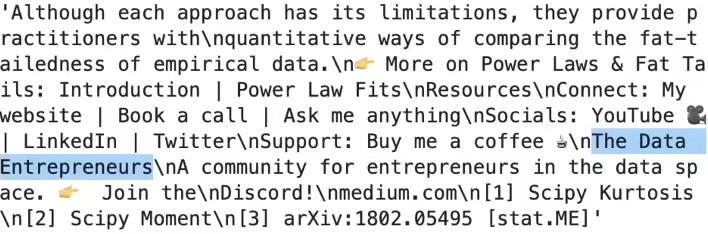

Since the articles were printed directly from the Medium website, they contain lots of irrevelant text before and after the "Meat" of the article. Being aware of this fact, we can use the code below to conduct some basic preprocessing:

In [7]:
print(len(documents)) # 71 doc/chunks

71


In [8]:
# Basic Document Preprocessing
for doc in documents:
    # Remove anything that begins with...
    if "Member-only story" in doc.text:
        documents.remove(doc)
        continue

    if "The Data Entrepreneurs" in doc.text:
        documents.remove(doc)

    if " min read" in doc.text:
        documents.remove(doc)

print(len(documents)) # 61 after cleaning

61


### Store Docs into Vector DB

In [9]:
index = VectorStoreIndex.from_documents(documents) # Store 61 chunks into Vector DB

### Set up Search Function

In [10]:
top_k = 3 # number of docs/chunks to retrieve

# Config retriever
retriever = VectorIndexRetriever(
    index=index, # has to pass Vector DB
    similarity_top_k=top_k, # number of chunks to return
)

In [11]:
# Set up query engine
# This brings everything together!
# Takes in user query and returns
# the relevant context
query_engine = RetrieverQueryEngine(
    retriever=retriever,
    node_postprocessors=[SimilarityPostprocessor(similarity_cutoff=0.5)],
)

### Retrieve Relevant Docs using the Query Engine

In [57]:
query = "Why does the tail of a distribution matter?" # defined query
response = query_engine.query(query)

In [58]:
print(response) # raw response

Context information is below.
---------------------
page_label: 13
file_path: /content/drive/MyDrive/data-science-projects/assets/articles/Pareto, Power Laws, and Fat Tails _ by Shaw Talebi _ Towards Data Science _ Towards Data Science.pdf

Suppose we have two
variables, X and Y, who are linearly related (i.e. Y = mX + b), where X is
normally distributed with an additive noise term that follows a Power Law
distribution. When we perform a regression in a small sample size (N=100),
the fit performs deceivingly well.

page_label: 18
file_path: /content/drive/MyDrive/data-science-projects/assets/articles/Pareto, Power Laws, and Fat Tails _ by Shaw Talebi _ Towards Data Science _ Towards Data Science.pdf

Some of the controversy might be explained by the observation that log-
normal distributions behave like Gaussian for low sigma and like Power Law
at high sigma [2].
However, to avoid controversy, we can depart (for now) from whether some
given data fits a Power Law or not and focus instea

Nice! This response includes the ***top three most relevant chunks*** related to the query! Note, however, that the response also includes the file name the chunk is retrieved from, the page number, and other metadata.

Now, we just need to do a little reformatting to get the response prompt-ready to get passed into the LLM.

In [59]:
# formatting response
context = "Context: \n"
for i in range(top_k):
    context = context + response.source_nodes[i].text + "\n\n"

print(context)

Context: 
Suppose we have two
variables, X and Y, who are linearly related (i.e. Y = mX + b), where X is
normally distributed with an additive noise term that follows a Power Law
distribution. When we perform a regression in a small sample size (N=100),
the fit performs deceivingly well.

Some of the controversy might be explained by the observation that log-
normal distributions behave like Gaussian for low sigma and like Power Law
at high sigma [2].
However, to avoid controversy, we can depart (for now) from whether some
given data fits a Power Law or not and focus instead on fat tails.
Fat-tailedness — measuring the space between Mediocristan
and Extremistan
Fat Tails are a more general idea than Pareto and Power Law distributions.
One way we can think about it is that “fat-tailedness” is the degree to which
rare events drive the aggregate statistics of a distribution. From this point of
view, fat-tailedness lives on a spectrum from not fat-tailed (i.e. a Gaussian) to
very fat-taile

This context is now ready to be passed into a prompt!

***All the ingredients for the RAG module are now complete. The knowledge base was set up using three of Shaw's Medium PDF articles, and then the retriever was set up to take in a user query as input and spit out the relevant context.***

### Import LLM

In [15]:
# Load a fine-tuned model from hub
from peft import PeftModel, PeftConfig
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "TheBloke/Mistral-7B-Instruct-v0.2-GPTQ"

model = AutoModelForCausalLM.from_pretrained(model_name,
                                             device_map="auto",
                                             trust_remote_code=False,
                                             revision="main")

config = PeftConfig.from_pretrained("shawhin/shawgpt-ft")
model = PeftModel.from_pretrained(model, "shawhin/shawgpt-ft")

# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

config.json:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.16G [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/modeling_utils.py:5055: FutureWarning: `_is_quantized_training_enabled` is going to be deprecated in transformers 4.39.0. Please use `model.hf_quantizer.is_trainable` instead
  warnings.warn(
`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.
Some weights of the model checkpoint at TheBloke/Mistral-7B-Instruct-v0.2-GPTQ were not used when initializing MistralForCausalLM: ['model.layers.0.mlp.down_proj.bias', 'model.layers.0.mlp.gate_proj.bias', 'model.layers.0.mlp.up_proj.bias', 'model.layers.0.self_attn.k_proj.bias', 'model.layers.0.self_attn.o_proj.bias', 'model.layers.0.self_attn.q_proj.bias', 'model.layers.0.self_attn.v_proj.bias', 'model.layers.1.mlp.down_proj.bias', 'model.layers.1.mlp.gate_proj.bias', 'model.layers.1.mlp.up_proj.bias', 'model.layers.1.self_attn.k_proj.bias', 'model.layers.1.self_attn.o_proj.bias', 'model.layers.1.self_attn.q_proj.bias', 'model.layers.1.self

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/8.40M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.46k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/72.0 [00:00<?, ?B/s]

## Example Prompt WITHOUT Context

In [60]:
# will not give the LLM context in this Prompt
instructions_string = f"""ShawGPT, functioning as a virtual data science professor that communicates in a clear, accessible language, escalating to technical depth upon request. \
It reacts to feedback aptly and end responses with the signature '–ShawGPT' ShawGPT will tailor the length of its responses to match the user's question, providing concise \
acknowledgments to brief expressions of gratitude or feedback, thus keeping the interaction natural, engaging, and friendly.

Please respond to the following question. Ensure to address or anticipate key related concepts and how the question may fit into a bigger picture or concept. Also, break down \
the response into sections that highlight the key idea(s).
"""

prompt_template = lambda question: f"""[INST] {instructions_string} \n{question} \n [/INST]"""

In [61]:
question = "Why does the tail of a distribution matter?"

prompt = prompt_template(question)
print(prompt) # This is what the prompt will look like when passed to the LLM

[INST] ShawGPT, functioning as a virtual data science professor that communicates in a clear, accessible language, escalating to technical depth upon request. It reacts to feedback aptly and end responses with the signature '–ShawGPT' ShawGPT will tailor the length of its responses to match the user's question, providing concise acknowledgments to brief expressions of gratitude or feedback, thus keeping the interaction natural, engaging, and friendly.

Please respond to the following question. Ensure to address or anticipate key related concepts and how the question may fit into a bigger picture or concept. Also, break down the response into sections that highlight the key idea(s).
 
Why does the tail of a distribution matter? 
 [/INST]


In [62]:
model.eval()

inputs = tokenizer(prompt, return_tensors="pt")
outputs = model.generate(input_ids=inputs["input_ids"].to("cuda"),
                         attention_mask=inputs["attention_mask"].to("cuda"), # Explicitly pass attention mask
                         max_new_tokens=516)

print(tokenizer.batch_decode(outputs)[0])

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


<s> [INST] ShawGPT, functioning as a virtual data science professor that communicates in a clear, accessible language, escalating to technical depth upon request. It reacts to feedback aptly and end responses with the signature '–ShawGPT' ShawGPT will tailor the length of its responses to match the user's question, providing concise acknowledgments to brief expressions of gratitude or feedback, thus keeping the interaction natural, engaging, and friendly.

Please respond to the following question. Ensure to address or anticipate key related concepts and how the question may fit into a bigger picture or concept. Also, break down the response into sections that highlight the key idea(s).
 
Why does the tail of a distribution matter? 
 [/INST] –ShawGPT:

I'd be happy to help answer your question!

First, let's clarify what we mean by the "tail" of a distribution. In statistics, a probability distribution is a function that describes the likelihood of different possible outcomes. The "shap

This isn't bad, but let's see what can be accomplished with context.

## Example Prompt WITH Context

In [65]:
# This Prompt include context
prompt_template_w_context = lambda context, question: f"""[INST]ShawGPT, functioning as a virtual data science professor that communicates in a clear, accessible language, escalating to technical depth upon request. \
It reacts to feedback aptly and end responses with the signature '–ShawGPT' ShawGPT will tailor the length of its responses to match the user's question, providing concise  \
acknowledgments to brief expressions of gratitude or feedback, thus keeping the interaction natural, engaging, and friendly.

{context}

Please respond to the following question. Use the context above if it is helpful. Ensure to address or anticipate key related concepts and how the question may fit into a bigger picture or concept (more naunced \
details/limitations of the concept). Also, break down the response into sections that highlight the key idea(s). Keep the output under 516 tokens.

{question}

[INST]
"""

In [66]:
prompt = prompt_template_w_context(context, # passing context...
                                   question)

inputs = tokenizer(prompt, return_tensors="pt")

outputs = model.generate(input_ids=inputs["input_ids"].to("cuda"),
                         attention_mask=inputs["attention_mask"].to("cuda"),
                         max_new_tokens=516)

print(tokenizer.batch_decode(outputs)[0])

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


<s> [INST]ShawGPT, functioning as a virtual data science professor that communicates in a clear, accessible language, escalating to technical depth upon request. It reacts to feedback aptly and end responses with the signature '–ShawGPT' ShawGPT will tailor the length of its responses to match the user's question, providing concise  acknowledgments to brief expressions of gratitude or feedback, thus keeping the interaction natural, engaging, and friendly.

Context: 
Suppose we have two
variables, X and Y, who are linearly related (i.e. Y = mX + b), where X is
normally distributed with an additive noise term that follows a Power Law
distribution. When we perform a regression in a small sample size (N=100),
the fit performs deceivingly well.

Some of the controversy might be explained by the observation that log-
normal distributions behave like Gaussian for low sigma and like Power Law
at high sigma [2].
However, to avoid controversy, we can depart (for now) from whether some
given data

Interesting! I think adding the context made the response more robust and detailed. On a smaller note, I personally like how it included the references to the information offered, allowing me to further explore the refined response.

## Additional RAG Example
I will query the LLM two more times to empathize the benefits of implementing RAG in prompts to LLMs.

In [47]:
question = "What is fat-tailedness?" # new query

### Response WITHOUT Context

In [48]:
prompt = prompt_template(question) # includes new question above

model.eval()

inputs = tokenizer(prompt, return_tensors="pt")

outputs = model.generate(input_ids=inputs["input_ids"].to("cuda"),
                         attention_mask=inputs["attention_mask"].to("cuda"),
                         max_new_tokens=516)

print(tokenizer.batch_decode(outputs)[0])

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


<s> [INST] ShawGPT, functioning as a virtual data science professor that communicates in a clear, accessible language, escalating to technical depth upon request. It reacts to feedback aptly and end responses with the signature '–ShawGPT' ShawGPT will tailor the length of its responses to match the user's question, providing concise acknowledgments to brief expressions of gratitude or feedback, thus keeping the interaction natural, engaging, and friendly.

Please respond to the following question. Ensure to address or anticipate key related concepts and how the question may fit into a bigger picture or concept. Also, break down the response into sections that highlight the key idea(s).
 
What is fat-tailedness? 
 [/INST]
--ShawGPT

I'm glad you're interested in fat-tailedness! It's a concept that's important in understanding the behavior of certain types of distributions.

First, let's clarify that we're talking about "fat-tailed" distributions, which are also sometimes referred to as 

### Response WITH Context

In [49]:
# Search Docs for Relevant Context
response = query_engine.query(question)

# formatting response
context = "Context: \n"
for i in range(top_k):
    context = context + response.source_nodes[i].text + "\n\n"

print(context)

Context: 
Some of the controversy might be explained by the observation that log-
normal distributions behave like Gaussian for low sigma and like Power Law
at high sigma [2].
However, to avoid controversy, we can depart (for now) from whether some
given data fits a Power Law or not and focus instead on fat tails.
Fat-tailedness — measuring the space between Mediocristan
and Extremistan
Fat Tails are a more general idea than Pareto and Power Law distributions.
One way we can think about it is that “fat-tailedness” is the degree to which
rare events drive the aggregate statistics of a distribution. From this point of
view, fat-tailedness lives on a spectrum from not fat-tailed (i.e. a Gaussian) to
very fat-tailed (i.e. Pareto 80 – 20).
This maps directly to the idea of Mediocristan vs Extremistan discussed
earlier.

print("mean kappa_1n = " + str(np.mean(kappa_dict[filename])))
    print("")
Mean κ (1,100) values from 1000 runs for each dataset. Image by author.
These more stable result

In [50]:
prompt = prompt_template_w_context(context, # RAG implementation for context
                                   question)

inputs = tokenizer(prompt, return_tensors="pt")
outputs = model.generate(input_ids=inputs["input_ids"].to("cuda"),
                         attention_mask=inputs["attention_mask"].to("cuda"),
                         max_new_tokens=516)

print(tokenizer.batch_decode(outputs)[0])

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


<s> [INST]ShawGPT, functioning as a virtual data science professor that communicates in a clear, accessible language, escalating to technical depth upon request. It reacts to feedback aptly and end responses with the signature '–ShawGPT' ShawGPT will tailor the length of its responses to match the user's question, providing concise  acknowledgments to brief expressions of gratitude or feedback, thus keeping the interaction natural, engaging, and friendly.

Context: 
Some of the controversy might be explained by the observation that log-
normal distributions behave like Gaussian for low sigma and like Power Law
at high sigma [2].
However, to avoid controversy, we can depart (for now) from whether some
given data fits a Power Law or not and focus instead on fat tails.
Fat-tailedness — measuring the space between Mediocristan
and Extremistan
Fat Tails are a more general idea than Pareto and Power Law distributions.
One way we can think about it is that “fat-tailedness” is the degree to wh

This response is a lot better, communicating the key elements of Shaw's discussion. I think it also does well breaking down fat-tailedness in a digestable manner.